In [18]:
import numpy as np
from pathlib import Path

# ------------ 1.  设置实验数据 ------------
star_points = {
    'frequency': [6.38, 6.2, 6.02, 6.01, 6.0, 5.9, 5.0,
                  4.8, 4.763, 4.762, 4.759, 4.5,
                  3.846, 6.666, 8.25],                # kHz
    'heating':   [287.393788264347, 193.616801258866, 165.112956629879,
                  42.126115596758,  49.393907101534,  371.762594973729,
                  455.879839044447, 378.844180607177, 45.611693284959,
                  36.838562612508,  74.572478160620,  191.305603411685,
                  384.763981809354, 736.695071670842, 770.682554687554]
}

star_points = {
    'frequency': [6.38, 6.2, 6.02, 6.01, 6.0, 5.9, 5.0, 4.763, 4.762, 4.759, 4.5,
                  3.846, 6.666, 8.25],                # kHz
    'heating':   [287.393788264347, 193.616801258866, 165.112956629879,
                  42.126115596758,  49.393907101534,  371.762594973729,
                  378.844180607177, 45.611693284959,
                  36.838562612508,  74.572478160620,  191.305603411685,
                  384.763981809354, 736.695071670842, 770.682554687554]
}

# ------------ 2.  计算时间并统一缩放 ------------
scale_factor      = 86 / 135.5087462284        # ≈ 0.63494002
conversion_factor = 275/2                      # μs  (8.25 kHz → 137.5 μs)

star_points['time'] = [(8.25/f)*conversion_factor*scale_factor
                       for f in star_points['frequency']]

exp_points = np.column_stack((star_points['time'], star_points['heating']))
out_dir = Path('./outputs'); out_dir.mkdir(exist_ok=True)
experimental_points_path = out_dir / 'experimental_points.npy'
np.save(experimental_points_path, exp_points)

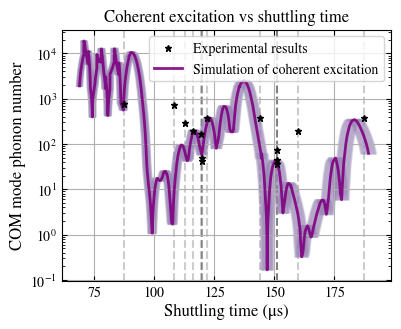

In [19]:
import numpy as np
import matplotlib
from pathlib import Path
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 12,
         "xtick.direction": "in",
         "xtick.major.pad": 3,
         "xtick.top": True,
         "ytick.labelsize": 12,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 12,
         "axes.labelpad": 3,
         "axes.grid": True
    }
)

out_dir = Path("./outputs")

t_avg = np.load(out_dir / "avg_curve_time.npy")        # shape (N,)
p_avg = np.load(out_dir / "avg_curve_phonon.npy")      # shape (N,)
exp_points = np.load(out_dir / "experimental_points.npy")

half_column_width_inches = 4.25
aspect_ratio = 1.3

# ------------------------------------------------------------------
# 1. Build many scaled-time curves (20 samples across ±3 σ)
scale_delta = 3.03 / 179.96
n_samples = 50
scales = np.linspace(1 - scale_delta, 1 + scale_delta, n_samples)

# t_scaled has shape (n_samples, N)
t_scaled = scales[:, None] * t_avg[None, :]

# 2. Envelope in time for every phonon value
t_min = t_scaled.min(axis=0)
t_max = t_scaled.max(axis=0)

# 3. Sort by phonon number so fill_betweenx doesn’t self-intersect
order = np.argsort(p_avg)
p_sorted   = p_avg[order]
t_min_sort = t_min[order]
t_max_sort = t_max[order]

# ------------------------------------------------------------------
plt.figure(figsize=(half_column_width_inches,
                    half_column_width_inches / aspect_ratio))

# # Shade the full envelope
# plt.fill_betweenx(p_sorted, t_min_sort, t_max_sort,
#                   color="#9c89b8", alpha=0.45,
#                   label="Trap frequency ±3σ", zorder=1)

# (Optional) show the individual realisations very faintly
for ts in t_scaled:
    plt.plot(ts, p_avg, color="#9c89b8", alpha=0.15, zorder=1)

# Experimental points
plt.plot(exp_points[:, 0], exp_points[:, 1], "k*", markersize=5,
         label="Experimental results", zorder=3)

# Central (mean) curve
plt.plot(t_avg, p_avg, "-", lw=2, color="purple", alpha=0.9,
         label="Simulation of coherent excitation", zorder=2)

# Vertical guide lines at experimental times (optional)
for tx in exp_points[:, 0]:
    plt.axvline(tx, color="black", linestyle="--", alpha=0.2, zorder=0)

plt.xlabel("Shuttling time (μs)", fontsize=12)
plt.ylabel("COM mode phonon number", fontsize=12)
plt.title("Coherent excitation vs shuttling time", fontsize=12)
plt.yscale("log")
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()

plt.savefig(out_dir / "Phonon_number_vs_shuttling_time_from_cache.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters:
rabi =  0.10041705695972267
nbar =  8.750926339971286
nalpha =  14.914827702103393


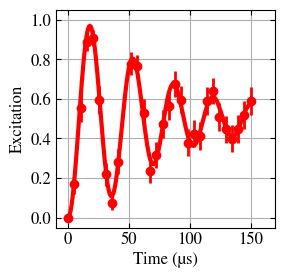

In [20]:
from qutip import *
from scipy.optimize import curve_fit
import math
import cmath
import timeit
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from time import time
from pynverse import inversefunc
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib
import h5py as h5
from scipy.special import eval_laguerre
from scipy.integrate import dblquad, quad
import scipy

# Update matplotlib settings for consistent appearance in plots
matplotlib.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "xtick.labelsize": 12,
        "xtick.direction": "in",
        "xtick.major.pad": 3,
        "xtick.top": True,
        "ytick.labelsize": 12,
        "ytick.direction": "in",
        "ytick.right": True,
        "axes.labelsize": 12,
        "axes.labelpad": 3,
        "axes.grid": True,
    }
)

# File loading function
def file_loading(
    data_path,
    date,
    index,
    number,
    x="rabi_t",
    y="pmt_counts_avg_thresholded",
    exp="RabiTimeScan",
):
    file_path = data_path + date + index + f"/0000{number}-" + exp + ".h5"

    with h5.File(file_path, "r") as file:
        datasets_keys = list(file["datasets"].keys())
        print("Datasets available:", datasets_keys)
        x_data = file["datasets"][x][:]
        y_data = file["datasets"][y][:]

    return x_data, y_data, np.linspace(np.min(x_data), np.max(x_data), 300)


###########################################
# Load and preprocess the data
###########################################

n_samples = 50

# Specify the data path and file details
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30462

rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
rabi_t = np.array(rabi_t)
pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

# Remove unwanted indices if needed
indices_to_remove = [9]
keep_indices = np.ones(len(rabi_t), dtype=bool)
keep_indices[indices_to_remove] = False
rabi_t = rabi_t[keep_indices]
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

# Data re-scaling
errorbar = (
    (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples))
    / np.max(pmt_counts_avg_thresholded)
)
pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.1

###########################################
# Define the model and fit parameters
###########################################

n_ions = 9
N = 300

INTENSITY_DISTRIBUTION = np.array(
    [0.96912696, 0.9844114, 0.99344862, 0.99840835, 1.0, 0.99840835, 0.99344862, 0.9844114, 0.96912696],
    dtype=float,
)
INTENSITY_WEIGHTS = np.array([2.0, 2.0, 2.0, 2.0, 1.0], dtype=float)  # Legacy weighting
USED_INTENSITIES = INTENSITY_DISTRIBUTION[: INTENSITY_WEIGHTS.size]

ETA = 0.23 / np.sqrt(n_ions)
ETA_SQ = ETA ** 2

_LAGUERRE_CACHE = {}


def _laguerre_values(N):
    if N not in _LAGUERRE_CACHE:
        _LAGUERRE_CACHE[N] = eval_laguerre(np.arange(N), ETA_SQ)
    return _LAGUERRE_CACHE[N]


def _displaced_thermal_diagonal(N, nbar_fit, nalpha_fit):
    ndisplace_fit = 1j * np.sqrt(nalpha_fit)
    displaced = displace(N, ndisplace_fit)
    rho_th = thermal_dm(N, nbar_fit)
    diag = (displaced * rho_th * displaced.dag()).diag()
    diag = np.abs(np.asarray(diag))
    return diag.astype(float)


def _pe_model_core(time, rabi_0_fit, nbar_fit, nalpha_fit, N, return_diag):
    time = np.asarray(time, dtype=float)
    diag = _displaced_thermal_diagonal(N, nbar_fit, nalpha_fit)
    laguerre_vals = _laguerre_values(N)
    prefactor = (rabi_0_fit * laguerre_vals)[:, None] * time[None, :]

    pe_fit = np.zeros(time.size, dtype=float)
    diag_accum = np.zeros_like(diag) if return_diag else None

    for weight, intensity in zip(INTENSITY_WEIGHTS, USED_INTENSITIES):
        sin_term = np.sin(intensity * prefactor) ** 2
        pe_fit += weight * np.sum(diag[:, None] * sin_term, axis=0)
        if return_diag:
            diag_accum += weight * diag

    pe_fit /= n_ions
    if return_diag:
        diag_accum /= n_ions
        return pe_fit, diag_accum
    return pe_fit


def pe_model_optimized(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N):
    return _pe_model_core(time, rabi_0_fit, nbar_fit, nalpha_fit, N, return_diag=True)


def pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N):
    return _pe_model_core(time, rabi_0_fit, nbar_fit, nalpha_fit, N, return_diag=False)


def fit_model(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N):
    return pe_model_optimized_fitting(time, rabi_0_fit, nbar_fit, nalpha_fit, N=N)


bounds = ((0.05, 0, 0), (0.15, 10, 300))
initial_guess = [
    (bounds[0][0] + bounds[1][0]) / 2,
    (bounds[0][1] + bounds[1][1]) / 2,
    (bounds[0][2] + bounds[1][2]) / 2,
]

popt, pcov = curve_fit(
    fit_model,
    rabi_t,
    pmt_counts_avg_thresholded,
    p0=initial_guess,
    bounds=bounds,
)
fitted_rabi, fitted_nbar, fitted_nalpha = popt

print("Fitted parameters:")
print("rabi = ", fitted_rabi)
print("nbar = ", fitted_nbar)
print("nalpha = ", fitted_nalpha)

# Running simulation
# rabi =  fitted_rabi
rabi = fitted_rabi
nbar =  fitted_nbar
n_ions = 9
N = 300
nalpha = fitted_nalpha

# You already have these lines in your code
time = np.linspace(np.min(times), np.max(times), 200)

# Running simulation for different nalpha values
nbars = [nbar - 3, nbar, nbar + 3]
results = []

for nbar in nbars:
    D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha)
    results.append(D_population)

import os
# Create outputs directory if it doesn't exist
os.makedirs("./outputs/shuttling/", exist_ok=True)

np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

# Plotting
plt.figure(figsize=(2.83, 2.83))
errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
# plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
# plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\\bar{{n}}_{{th}} = {np.average(nbars):.1f} \\pm {(np.average(nbars) - nbars[0]):.1f}$')
plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
# plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
# plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 170)
# plt.legend(loc='lower right')
# plt.legend()
plt.grid(True)
plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight') 
plt.show()

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.14999999998798316 ± 1.806214115064656
nbar =  0.1633420390740346 ± 15.209529253750963
nalpha =  209.53121688260754 ± 410.8263488660257


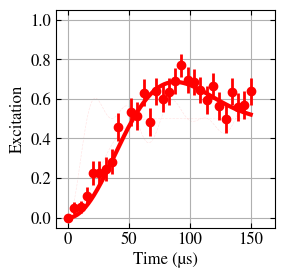

rabi =  0.14999999998798316 ± 1.806214115064656 
nbar =  0.1633420390740346 ± 15.209529253750963 
nalpha =  209.53121688260754 ± 410.8263488660257


In [21]:
def heating_rate_processing(data_path, date, index, number, bounds = ((0.02, 0, 1), (0.15, 23, 500))):
    n_samples = 50

    rabi_t, pmt_counts_avg_thresholded, times = file_loading(data_path, date, index, number)
    rabi_t = np.array(rabi_t)  # Convert list to numpy array if not already
    pmt_counts_avg_thresholded = np.array(pmt_counts_avg_thresholded)

    # Remove unwanted indices if needed
    indices_to_remove = [9]  # Added 12 to the list
    keep_indices = np.ones(len(rabi_t), dtype=bool)  # Initially set all to True
    keep_indices[indices_to_remove] = False
    rabi_t = rabi_t[keep_indices]
    pmt_counts_avg_thresholded = pmt_counts_avg_thresholded[keep_indices]

    # Data re-scaling
    errorbar = (np.sqrt(pmt_counts_avg_thresholded) / np.sqrt(n_samples)) / np.max(pmt_counts_avg_thresholded)
    pmt_counts_avg_thresholded = np.max(pmt_counts_avg_thresholded) - pmt_counts_avg_thresholded
    pmt_counts_avg_thresholded = pmt_counts_avg_thresholded / np.max(pmt_counts_avg_thresholded) / 1.3

    # Initial guesses
    # initial_guess = [0.09832203238100552, 0, 100]  # [rabi, nbar, nalpha]
    # bounds = ((0.05, 0, 0), (0.15, 30, 1))  # Modified upper bound for nalpha to 5
    # bounds = ((0.0, 0, 0), (0.15, np.inf, np.inf))
    # Initial guess is the center of the bounds
    initial_guess = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2, (bounds[0][2] + bounds[1][2]) / 2]

    # Perform the curve fitting
    popt, pcov = curve_fit(fit_model, rabi_t, pmt_counts_avg_thresholded, p0=initial_guess, bounds=bounds)
    fitted_rabi, fitted_nbar, fitted_nalpha = popt

    with np.errstate(invalid='ignore'):
        perr = np.sqrt(np.diag(pcov))
    perr = np.where(np.isfinite(perr), perr, np.nan)
    fitted_rabi_err, fitted_nbar_err, fitted_nalpha_err = perr

    print("Fitted parameters (±1σ):")
    print("rabi = ", fitted_rabi, "±", fitted_rabi_err)
    print("nbar = ", fitted_nbar, "±", fitted_nbar_err)
    print("nalpha = ", fitted_nalpha, "±", fitted_nalpha_err)

    # Running simulation
    # rabi =  fitted_rabi
    rabi = fitted_rabi
    nbar =  fitted_nbar
    # n_ions = 9
    # N = 400
    nalpha = fitted_nalpha

    # You already have these lines in your code
    time = np.linspace(np.min(times), np.max(times), 200)

    # Running simulation for different nalpha values
    nbars = [nbar - 3, nbar, nbar + 3]
    results = []

    for nbar in nbars:
        D_population, _ = pe_model_optimized(time, rabi_0_fit=rabi, nbar_fit=nbar, nalpha_fit=nalpha, N=500)
        results.append(D_population)

    # Create outputs directory if it doesn't exist
    os.makedirs("./outputs/shuttling/", exist_ok=True)

    np.save("./data/save_rabi_t_shuttling_static.npy", rabi_t)
    np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy", pmt_counts_avg_thresholded)
    np.save("./data/save_rabi_t_shuttling_static_simulation.npy", time)
    np.save("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy", results)

    rabi_t = np.load("./data/save_rabi_t_shuttling_static.npy")
    pmt_counts_avg_thresholded = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static.npy")
    time = np.load("./data/save_rabi_t_shuttling_static_simulation.npy")
    results = np.load("./data/save_pmt_counts_avg_thresholded_shuttling_static_simulation.npy")

    # Plotting
    plt.figure(figsize=(2.83, 2.83))
    errorbar = np.sqrt(pmt_counts_avg_thresholded * (1 - pmt_counts_avg_thresholded)) / np.sqrt(n_samples)
    plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='red', lw=2, zorder=2, label='Data')
    # plt.scatter(rabi_t[:], pmt_counts_avg_thresholded[:], c='red', s=30, zorder=2, label='Data')
    # plt.errorbar(rabi_t[:], pmt_counts_avg_thresholded[:], yerr=errorbar[:], fmt='o', c='C0', lw=1, zorder=2, label='Data')
    plt.plot(time, results[1], c='red', lw=3, zorder=3, label=f'$\bar{{n}}_{{th}} = {np.average(nbars):.1f} \pm {(np.average(nbars) - nbars[0]):.1f}$')
    plt.plot(time, results[0], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
    plt.plot(time, results[2], '--', c='red', lw=0.5, zorder=1, alpha=0.1)
    # plt.fill_between(time, results[0], results[2], color='red', alpha=0.3)
    # plt.title('9-ion rabi oscillation after half speed shuttling', fontdict={'family': 'STIXGeneral', 'size': 12})
    plt.xlabel(r'Time (µs)', fontdict={'family': 'STIXGeneral', 'size': 12})
    plt.ylabel(r'Excitation', fontdict={'family': 'STIXGeneral', 'size': 12})
    plt.ylim(-0.05, 1.05)
    plt.xlim(-10, 170)
    # plt.legend(loc='lower right')
    # plt.legend()
    plt.grid(True)
    plt.savefig('./outputs/shuttling/Rabi_9_ions_no_shuttling.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    return (
        fitted_rabi,
        fitted_nbar,
        fitted_nalpha,
        fitted_rabi_err,
        fitted_nbar_err,
        fitted_nalpha_err,
    )

# Specify the data path and file details
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "20"
number = 30516
(
    rabi,
    nbar,
    nalpha,
    rabi_err,
    nbar_err,
    nalpha_err,
) = heating_rate_processing(data_path, date, index, number)
print("rabi = ", rabi, "±", rabi_err, "\nnbar = ", nbar, "±", nbar_err, "\nnalpha = ", nalpha, "±", nalpha_err)


Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.049560467034452174 ± 0.0020030960169134904
nbar =  21.92527954819394 ± 5.915579169752704
nalpha =  46.17978723798429 ± 8.160423012445744


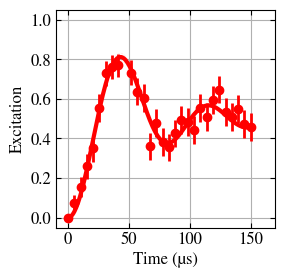

rabi =  0.049560467034452174 ± 0.0020030960169134904 
nbar =  21.92527954819394 ± 5.915579169752704 
nalpha =  46.17978723798429 ± 8.160423012445744


In [22]:
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30424
(
    rabi,
    nbar,
    nalpha,
    rabi_err,
    nbar_err,
    nalpha_err,
) = heating_rate_processing(data_path, date, index, number)
print("rabi = ", rabi, "±", rabi_err, "\nnbar = ", nbar, "±", nbar_err, "\nnalpha = ", nalpha, "±", nalpha_err)

Datasets available: ['fit_signal', 'pmt_counts', 'pmt_counts_avg_thresholded', 'rabi_t']
Fitted parameters (±1σ):
rabi =  0.10100821013415731 ± 0.0030026228995777148
nbar =  9.999999999993381 ± 6.02710757450508
nalpha =  16.35171057036238 ± 7.36945309784235


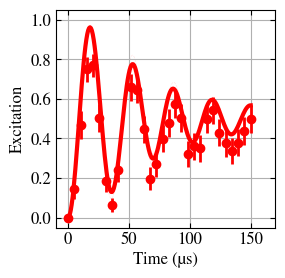

rabi =  0.10100821013415731 ± 0.0030026228995777148 
nbar =  9.999999999993381 ± 6.02710757450508 
nalpha =  16.35171057036238 ± 7.36945309784235


In [23]:
data_path = "/Users/bingran_you/Library/CloudStorage/OneDrive-Personal/UCB STUDY/Research/Multiplexing/artiq_working_dir - 20240329/"
date = "2024-10-27/"
index = "19"
number = 30462
(
    rabi,
    nbar,
    nalpha,
    rabi_err,
    nbar_err,
    nalpha_err,
) = heating_rate_processing(data_path, date, index, number, bounds = ((0.05, 0, 0), (0.15, 10, 300)))
print("rabi = ", rabi, "±", rabi_err, "\nnbar = ", nbar, "±", nbar_err, "\nnalpha = ", nalpha, "±", nalpha_err)